# Моделирование

In [1]:
from IPython.display import Image

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import precision_score, recall_score, f1_score

### Машинное обучение (ML)

Машинное обучение (англ. machine learning, ML) — класс методов искусственного интеллекта, характерной чертой которых является не прямое решение задачи, а обучение за счёт применения решений множества сходных задач. <i>(Википедия)</i>

### Обучение без учителя

Нет разметки, нет сигнала из вне. Поиск зависимостей внутри данных, снижение размерности

Примеры:
- выделить группы людей однородные по демографическим признакам (пол, возраст, доход ...)
- разбить покупателей на группы покупающие похожие товары
- сгруппировать тексты по теме (отзывы на товар, вопросы в чат)
- сократить размерность данных с минимальной потерей информации
- детекция аномалий, автоматически определяем отклонения от нормы

### Обучение с учителем

Есть разметка, целевой показатель который хотим предсказать

Примеры:
- предсказание температуры завтра
- кредитный скоринг
- прогноз зарплаты футболиста
- прогноз котировок акций
- определение темы текста
- распознавание изображений (кот или пес на фото)

### Кластеризация

Кластерный анализ — задача разбиения заданной выборки объектов на подмножества, называемые кластерами, так, чтобы каждый кластер состоял из схожих объектов, а объекты разных кластеров существенно отличались.

- выделить группы людей однородные по демографическим признакам (пол, возраст, доход ...)
- разбить покупателей на группы покупающие похожие товары
- сгруппировать тексты по теме
- выделить компании, акции которых часто движутся в одном направлении (коррелируют друг с другом), чтобы не инвестировать в похожие для разделения рисков

Все это примеры задач, которые можно решить с помощью кластеризации.

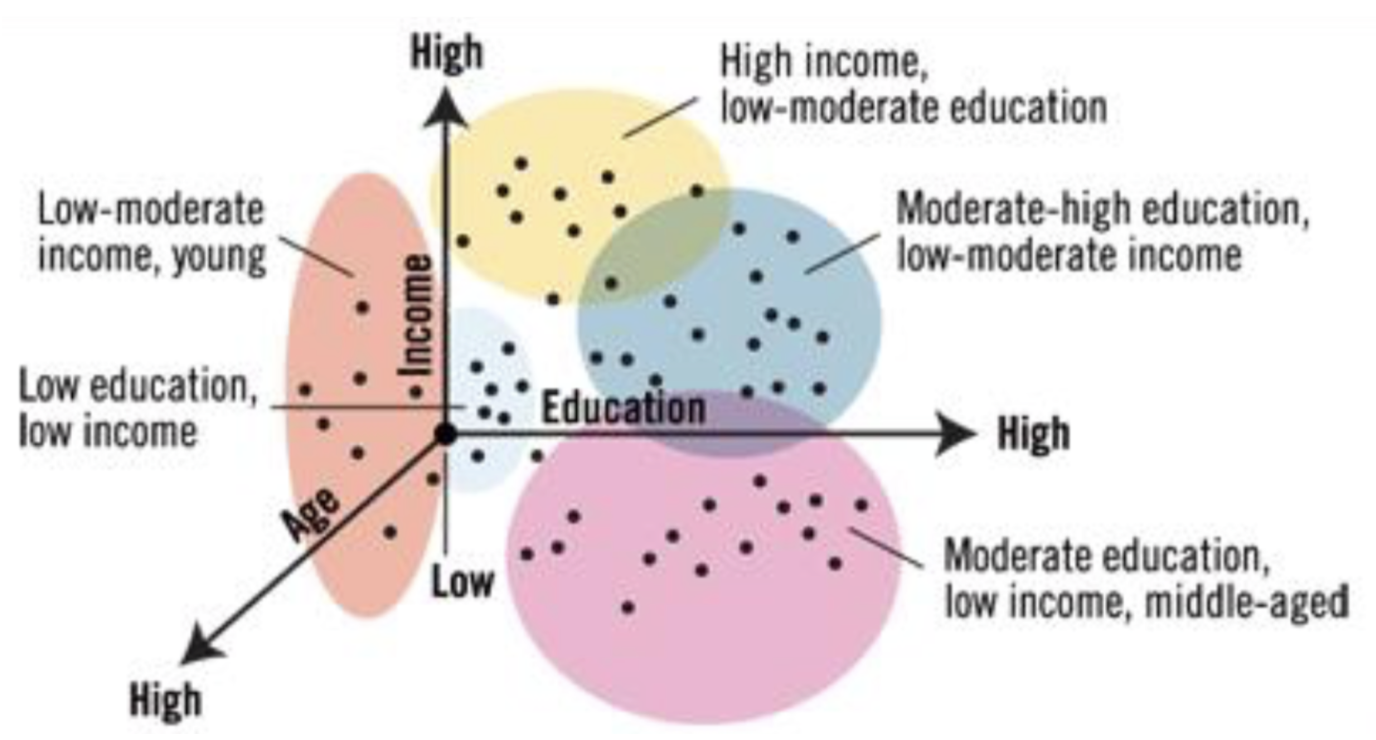

In [3]:
Image('image/1.png')

Результатом кластеризации является номер кластера для каждого объекта и центры кластеров (характерные представители).

### Алгоритмы кластеризации

Не существует универсального алгоритма, который был бы лучшим во всех задачах. Каждый раз стоит подбирать алгоритм исходя из целей.

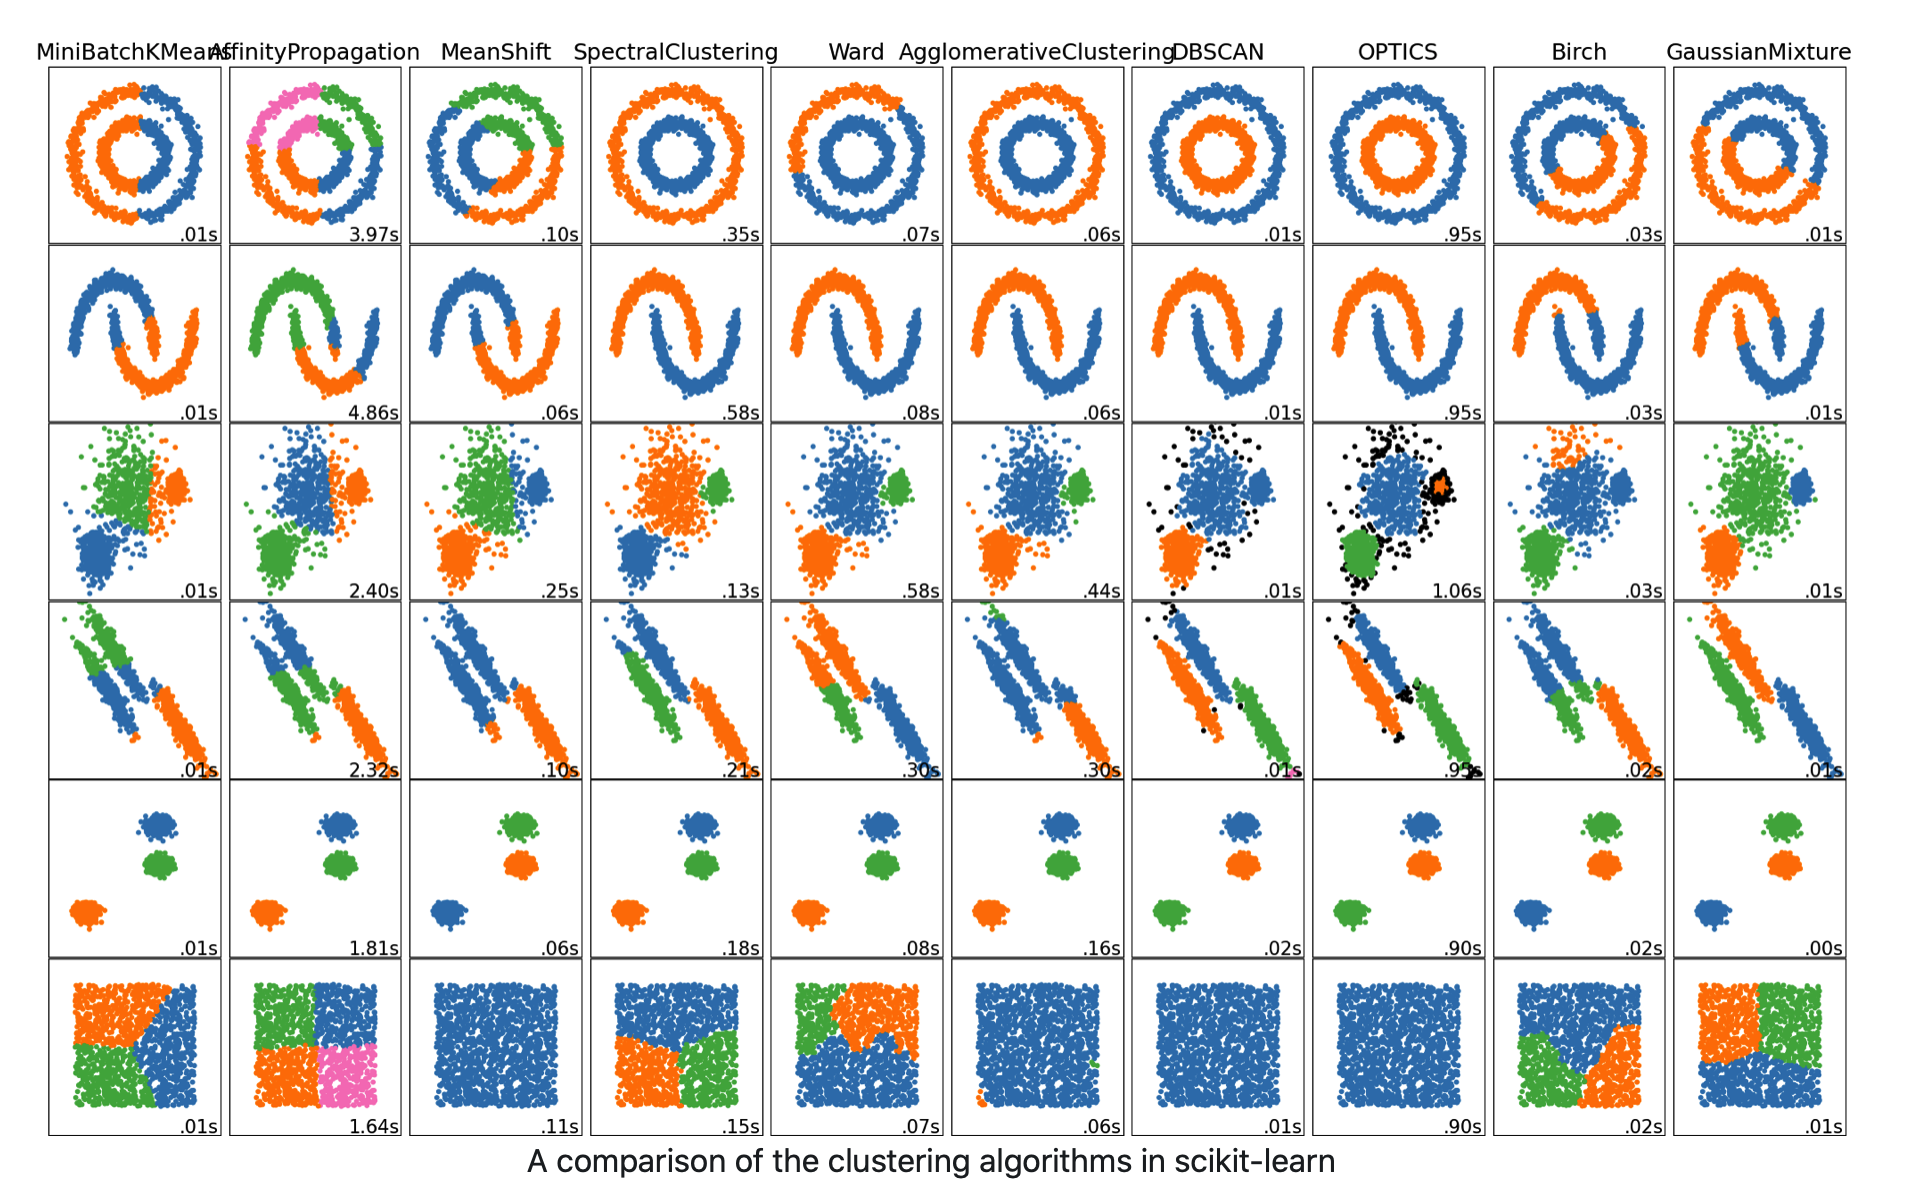

In [4]:
Image('image/2.png')

### Kmeans

Метод k-средних очень популярен и является достаточно универсальным.

Особенность - необходимо выбирать количество кластеров.

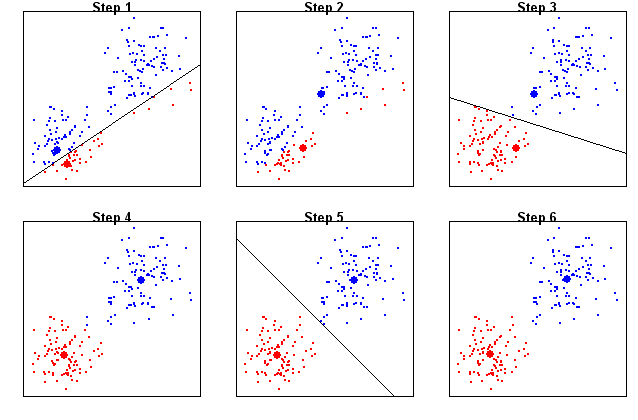

In [5]:
Image('image/3.png')

In [6]:
df = pd.read_csv('Iris.csv')

In [7]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [8]:
df.groupby(by='Species')['Id'].count()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: Id, dtype: int64

In [9]:
df.groupby(by='Species').mean()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,,
Iris-setosa,25.5,5.006,3.418,1.464,0.244
Iris-versicolor,75.5,5.936,2.770,4.260,1.326
Iris-virginica,125.5,6.588,2.974,5.552,2.026


In [10]:
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

In [11]:
from sklearn.cluster import KMeans

In [12]:
kmeans = KMeans(n_clusters=3)
df['n_clust'] = kmeans.fit_predict(df[features]) 

In [13]:
pd.pivot_table(df, index='Species', columns='n_clust', aggfunc={'Id': 'count'})

Id            
n_clust             0     1     2
Species                          
Iris-setosa       NaN   NaN  50.0
Iris-versicolor   2.0  48.0   NaN
Iris-virginica   36.0  14.0   NaN

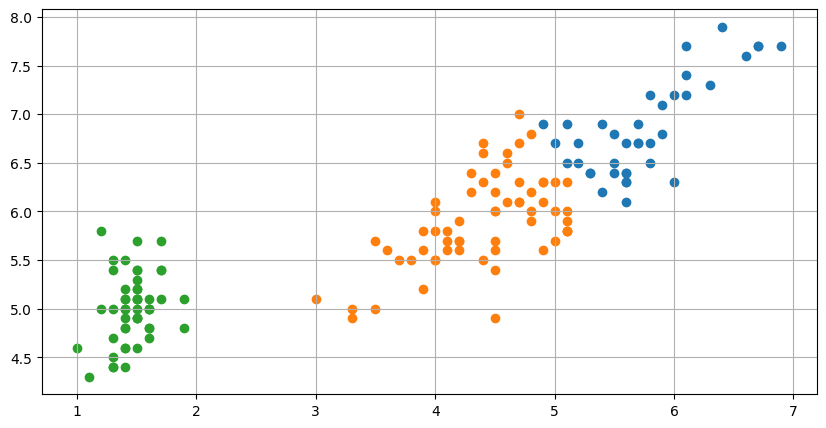

In [14]:
plt.figure(figsize=(10,5))
for i in range(0, 4):
    plt.scatter(df[df['n_clust'] == i]['PetalLengthCm'], df[df['n_clust'] == i]['SepalLengthCm'])
plt.grid()
plt.show()

### Как определить оптимальное число кластеров?

#### inertia - сумма квадратов расстояний от каждого объекта до центра ближайшего кластера

In [15]:
metrics = []
for i in range(1,9):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(df[features]) 
    metrics.append([i, kmeans.inertia_])
metrics = np.array(metrics)

In [16]:
metrics

array([[  1.        , 680.8244    ],
       [  2.        , 152.36870648],
       [  3.        ,  78.94084143],
       [  4.        ,  57.31787321],
       [  5.        ,  46.55405385],
       [  6.        ,  38.93096305],
       [  7.        ,  34.31894428],
       [  8.        ,  30.08530769]])

#### Метод локтя

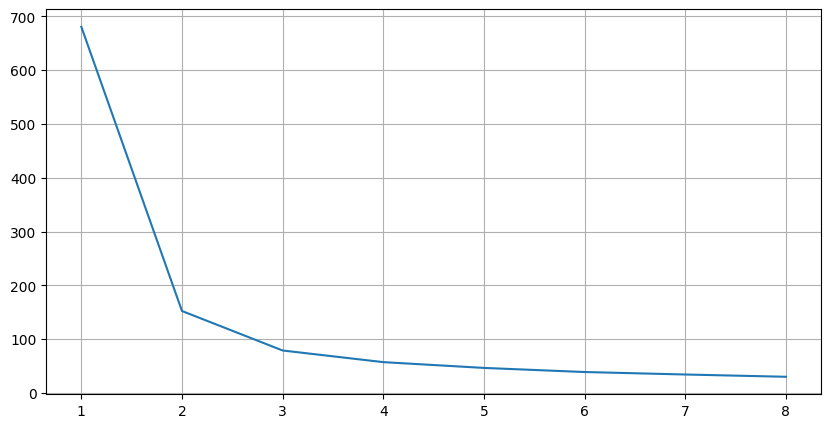

In [17]:
plt.figure(figsize=(10,5))
plt.plot(metrics[:,0], metrics[:,1])
plt.grid()
plt.show()

### Стандартизация и зачем она нужна

Цель стандартизации - выровнять влияние признаков на результат. Геометрически избежать сильного вытягивания данных вдоль некоторых осей.

Например - кластеризуем людей по зарплате и образованию. Зарплата в рублях, образование от 1 до 5 (1 - среднее, 5 - доктор наук).

Расстояние между  [1000, 1] и [1000,5] равно 4
Расстояние между [1000, 1] и [1010, 1] равно 10

Отличие в 1% по зарплате оказало большее влияние на расстояние, чем максимальное отличие в образовании. 

Вариант решения проблемы - стандартизация. Вычитаем из значений среднее и делим на стандартное отклонение `https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html`

так мы приведем все признаки к среднему значению ноль и стандартному отклонению 1. Тем самым выровняв их влияние на расстояние между объектами.

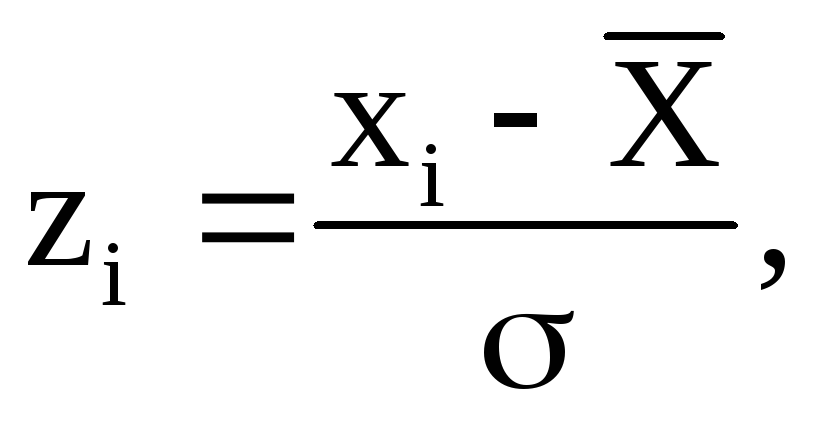

In [18]:
Image('image/4.png')

### Основные шаги

- подготовить данные
- решить что считаем расстоянием между объектами
- определиться с алгоритмом
- реализовать все это дело
- посмотреть что вышло
- если результат не удовлетворяет - повторить с начала)

## Обучение с учителем

### Задача бинарной классификации

- вернет или не вернет заемщик кредит 
- кот или собака на изображении
- стоит ли отправить письмо в спам

In [19]:
df = pd.read_csv('Iris.csv')

#### Относится ли данный цветок к сорту Virginica?

In [20]:
df['target'] = (df['Species'] == 'Iris-virginica').astype(int)

In [21]:
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

In [22]:
df['is_test'] = (np.random.rand(len(df)) > 0.5).astype(int)

df_train = df[df['is_test'] == 0].reset_index()
df_test = df[df['is_test'] == 1].reset_index()

In [23]:
from sklearn.neighbors import KNeighborsClassifier

In [24]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(df_train[features], df_train['target'])
df_test['knn_pred'] = model.predict(df_test[features])

In [25]:
model.predict(df_test[features])

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1])

In [26]:
pd.pivot_table(df_test, index='target', columns='knn_pred', aggfunc={'Id': 'count'})

Id      
knn_pred     0     1
target              
0         47.0   4.0
1          NaN  19.0

### Confusion matrix

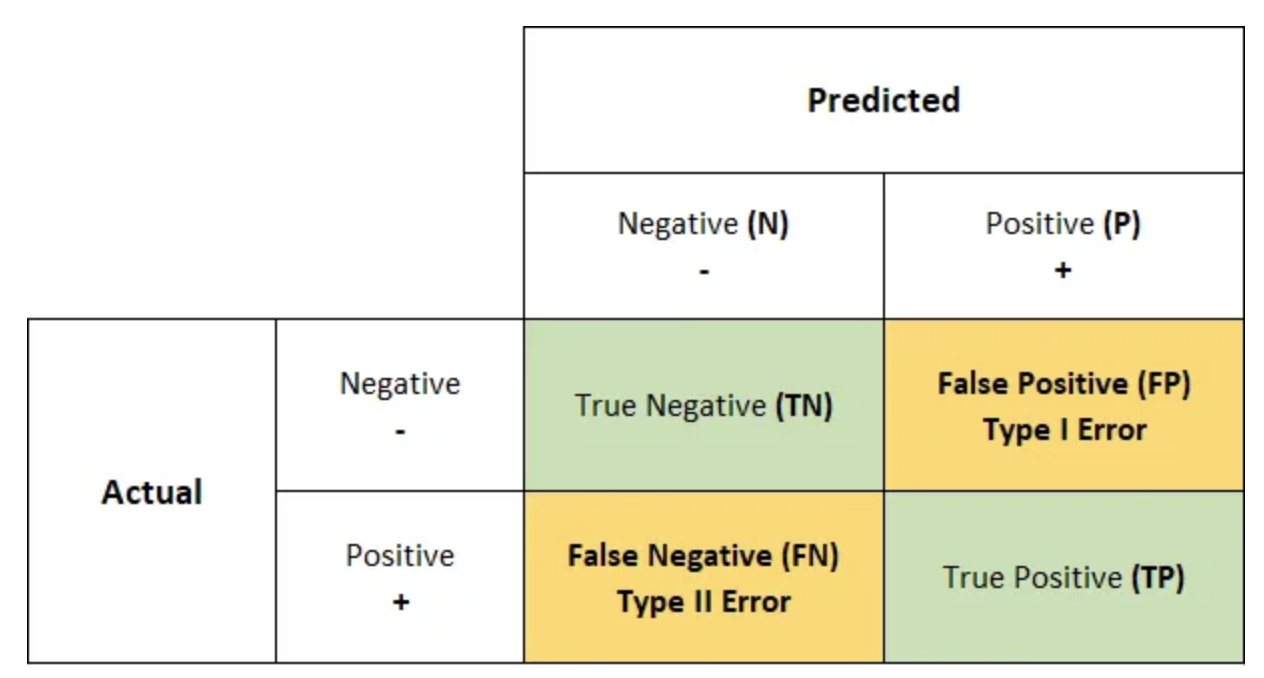

In [27]:
Image('image/10.png')

precision (точность) - доля верно угаданных от предсказанных

recall (полнота) - доля найденных классификатором от всех в тестовой выборке

In [28]:
TP = 27
TN = 37
FN = 3
FP = 1

In [29]:
pr = TP/(TP+FP)
rec = TP/(TP+FN)

In [30]:
pr, rec

(0.9642857142857143, 0.9)

In [31]:
import catboost as cb

In [32]:
model = cb.CatBoostClassifier(iterations=10)

In [33]:
model.fit(df_train[features], df_train['target'])
df_test['cat_pred'] = model.predict(df_test[features])

Learning rate set to 0.239086
0:	learn: 0.5994557	total: 47.4ms	remaining: 427ms
1:	learn: 0.5056063	total: 48.4ms	remaining: 193ms
2:	learn: 0.4419896	total: 49.3ms	remaining: 115ms
3:	learn: 0.3785048	total: 50ms	remaining: 75ms
4:	learn: 0.3275634	total: 50.8ms	remaining: 50.8ms
5:	learn: 0.2841125	total: 51.4ms	remaining: 34.2ms
6:	learn: 0.2587859	total: 51.9ms	remaining: 22.3ms
7:	learn: 0.2354625	total: 52.5ms	remaining: 13.1ms
8:	learn: 0.2177196	total: 53ms	remaining: 5.89ms
9:	learn: 0.2021703	total: 53.6ms	remaining: 0us


In [34]:
pd.pivot_table(df_test, index='target', columns='cat_pred', aggfunc={'Id': 'count'})

Id    
cat_pred   0   1
target          
0         49   2
1          1  18

### Можно получить не только вердикт, но и предсказанные вероятности отнесения к объекту

In [35]:
model.predict(df_test[features])

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1])

In [36]:
model.predict_proba(df_test[features])[:10]

array([[0.89510858, 0.10489142],
       [0.89049569, 0.10950431],
       [0.89049569, 0.10950431],
       [0.89049569, 0.10950431],
       [0.89510858, 0.10489142],
       [0.89049569, 0.10950431],
       [0.80869832, 0.19130168],
       [0.86541293, 0.13458707],
       [0.8986615 , 0.1013385 ],
       [0.86541293, 0.13458707]])

### ROC_AUC

#### метрика которая позволяет оценить насколько хорошо отранжирован прогноз

#### идеальная ситуация когда отранжировав по предсказанным вероятностям мы получим все нули слева, а единицы справа

0, 0, 0, 0, 0, 1, 1, 1

In [37]:
from sklearn import metrics

In [38]:
fpr, tpr, thresholds = metrics.roc_curve(df_test['target'], model.predict_proba(df_test[features])[:,1])

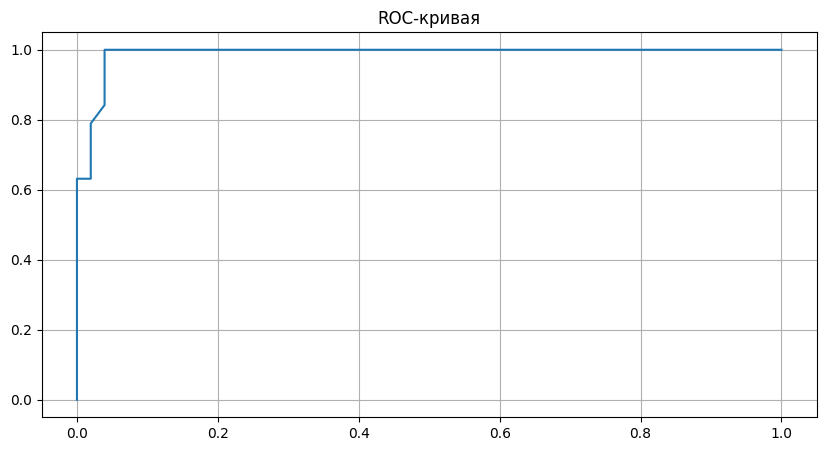

In [39]:
plt.figure(figsize=(10,5))
plt.plot(fpr, tpr)
plt.grid()
plt.title('ROC-кривая')
plt.show()

In [40]:
metrics.roc_auc_score(df_test['target'], model.predict_proba(df_test[features])[:,1])

0.9891640866873066

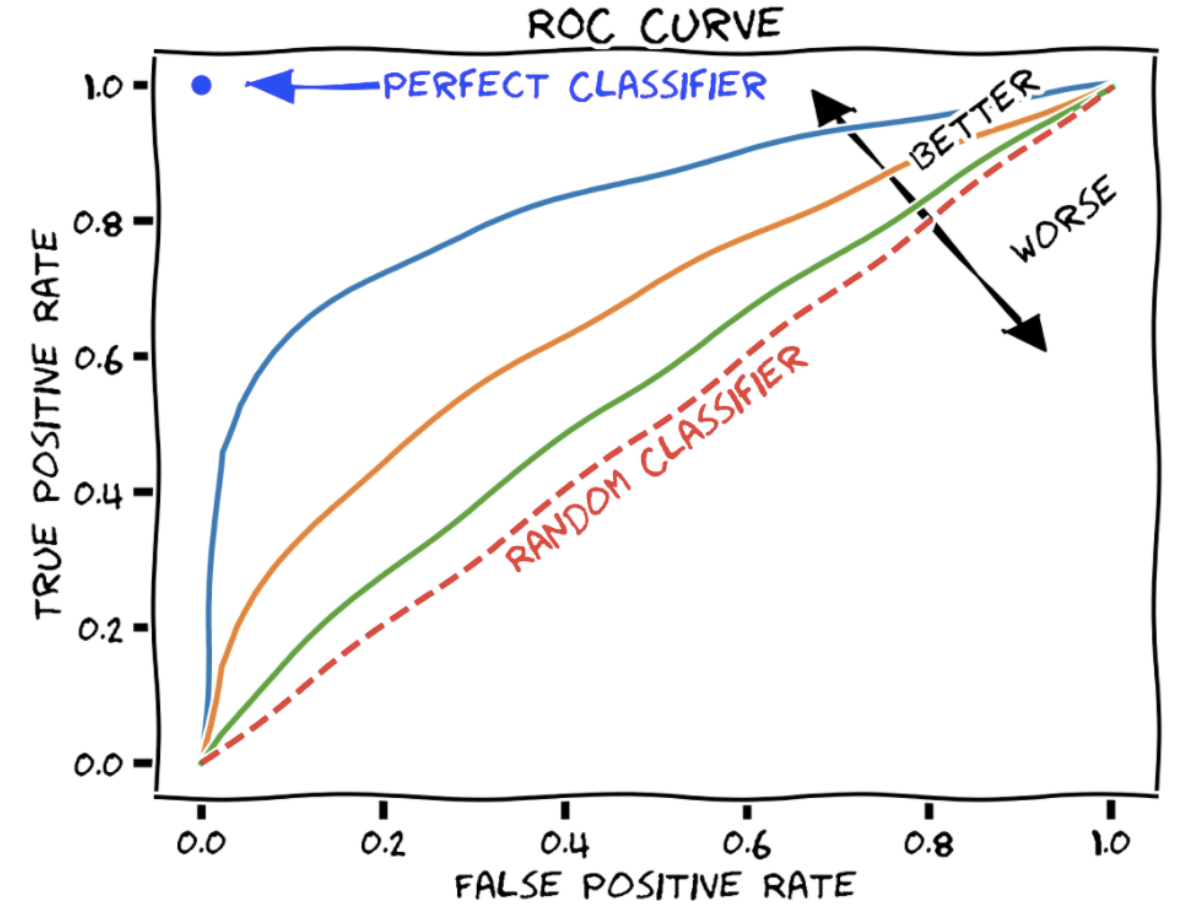

In [41]:
Image('image/11.png')

### Переход от вероятности к классам

Если алгоритм на выходе отдает предсказанные вероятности, то это дает некоторую свободу при переходе к конечным ответам. За счет изменения порогового значения мы можем выбирать что нам важнее, точность или полнота.
1 если predict_proba > limit, иначе 0

#### Подробнее в домашнем задании)

### Задача регрессии

предсказываем вещественное значение

знакомый пример из дипдайва по прогнозу зарплаты футболистов

In [42]:
df = pd.read_csv('FIFA20_official_data.csv')

In [43]:
features = ['Crossing', 'Finishing', 'HeadingAccuracy',
       'ShortPassing', 'Volleys', 'Dribbling', 'Curve', 'FKAccuracy',
       'LongPassing', 'BallControl', 'Acceleration', 'SprintSpeed', 'Agility',
       'Reactions', 'Balance', 'ShotPower', 'Jumping', 'Stamina', 'Strength',
       'LongShots', 'Aggression', 'Interceptions', 'Positioning', 'Vision',
       'Penalties', 'Composure']

In [44]:
df = df[features + ['Value', 'ID']]

In [45]:
df.head()

,Crossing,Finishing,HeadingAccuracy,ShortPassing,Volleys,Dribbling,Curve,FKAccuracy,LongPassing,BallControl,...,Strength,LongShots,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Value,ID
0,80.0,91.0,83.0,82.0,90.0,85.0,86.0,82.0,77.0,84.0,...,86.0,86.0,87.0,41.0,92.0,84.0,83.0,85.0,€53M,176580
1,83.0,89.0,84.0,85.0,87.0,88.0,86.0,85.0,82.0,90.0,...,63.0,83.0,73.0,49.0,90.0,86.0,86.0,89.0,€69M,194765
2,87.0,77.0,58.0,86.0,86.0,85.0,86.0,87.0,87.0,87.0,...,67.0,89.0,70.0,74.0,83.0,88.0,90.0,86.0,€56.5M,212198
3,94.0,82.0,55.0,92.0,82.0,87.0,85.0,83.0,91.0,91.0,...,74.0,90.0,76.0,63.0,88.0,94.0,82.0,91.0,€90M,192985
4,87.0,66.0,57.0,81.0,68.0,87.0,88.0,78.0,78.0,87.0,...,80.0,81.0,84.0,78.0,81.0,82.0,76.0,87.0,€20M,224334


In [46]:
df.dropna(inplace=True)

In [47]:
def value_conv(v):
    if v[-1] == 'K':
        return float(v[1:-1])*10**3
    if v[-1] == 'M':
        return float(v[1:-1])*10**6
    return float(v[1:])

df.Value = df.Value.apply(value_conv)

df = df[df['Value'] != 0]

In [48]:
df['is_test'] = (np.random.rand(len(df)) > 0.5).astype(int)

df_train = df[df['is_test'] == 0].reset_index()
df_test = df[df['is_test'] == 1].reset_index()

In [49]:
from sklearn.neighbors import KNeighborsRegressor

In [50]:
model = KNeighborsRegressor(n_neighbors=3)
model.fit(df_train[features], df_train['Value'])
df_test['knn_pred'] = model.predict(df_test[features])

In [51]:
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error

In [52]:
knn_mae = np.mean(np.abs(df_test['knn_pred'] - df_test['Value']))
knn_rmse = np.sqrt(np.mean(np.power(df_test['knn_pred'] - df_test['Value'],2)))
knn_mape = np.mean(np.abs(df_test['knn_pred'] - df_test['Value'])/df_test['Value']) * 100

In [53]:
knn_mae, knn_rmse, knn_mape

(1152324.9470668826, 3057290.5140033923, 68.25474125123176)

## Другие модели для ранжирования

##### можно ли улучшить прогноз используя другие модели?

### CatBoost

In [54]:
import catboost as cb

In [55]:
model = cb.CatBoostRegressor()

In [56]:
model.fit(df_train[features], df_train['Value'], verbose=False, plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [57]:
df_test['cat_pred'] = model.predict(df_test[features])

In [58]:
cat_mae = np.mean(np.abs(df_test['cat_pred'] - df_test['Value']))
cat_rmse = np.sqrt(np.mean(np.power(df_test['cat_pred'] - df_test['Value'],2)))
cat_mape = np.mean(np.abs(df_test['cat_pred'] - df_test['Value'])/df_test['Value']) * 100

In [59]:
knn_mae, knn_rmse, knn_mape

(1152324.9470668826, 3057290.5140033923, 68.25474125123176)

In [60]:
cat_mae, cat_rmse, cat_mape

(762780.4714432759, 1974562.073275901, 56.804971294499786)

### "Деревяные" алгоритмы и градиентный бустинг

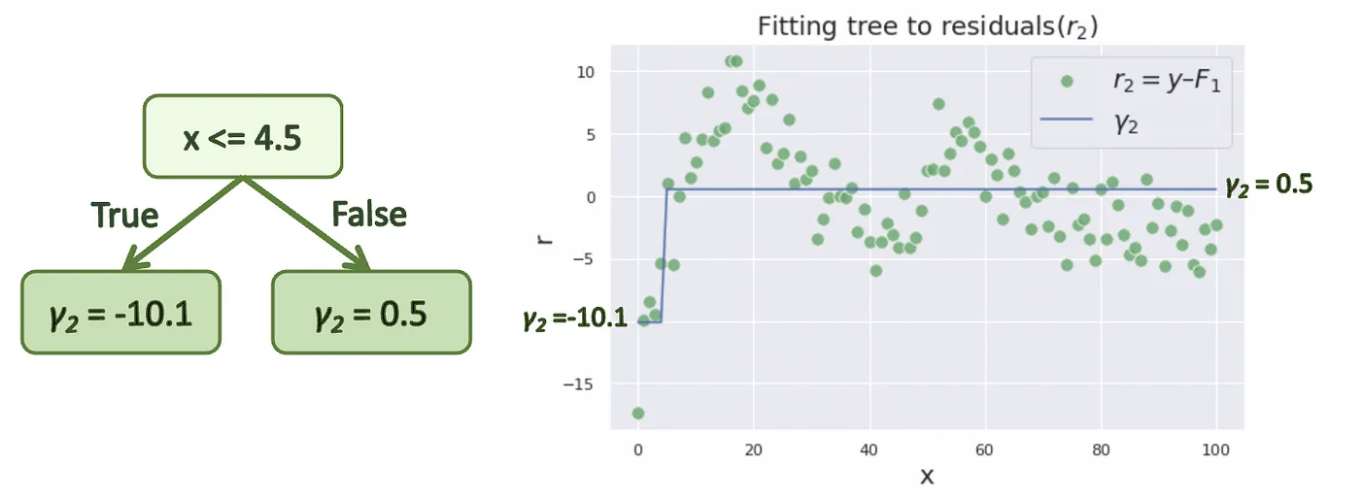

In [61]:
Image('image/8.png')

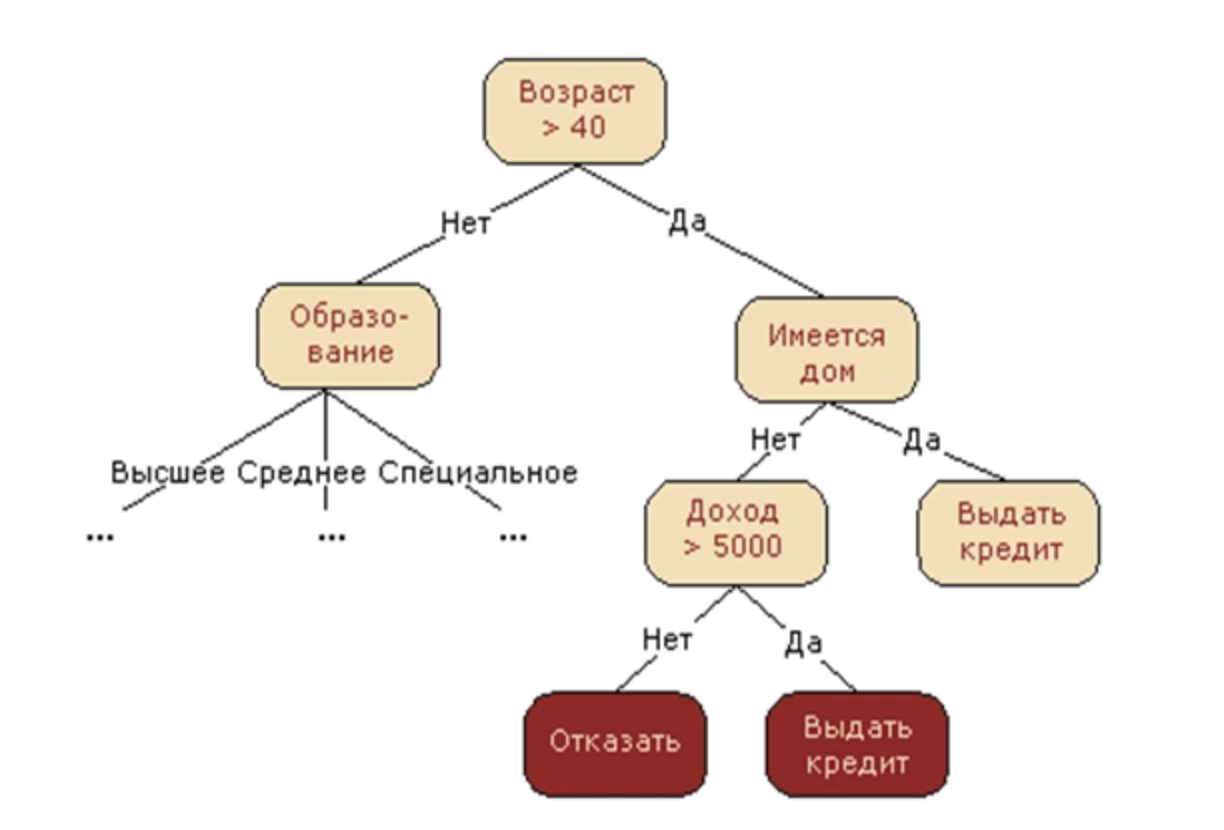

In [62]:
Image('image/5.png')

### Random Forest (случайный лес)

обучаем параллельно много деревьев (по разным выборкам и признакам), в качестве ответа усредняем их прогнозы

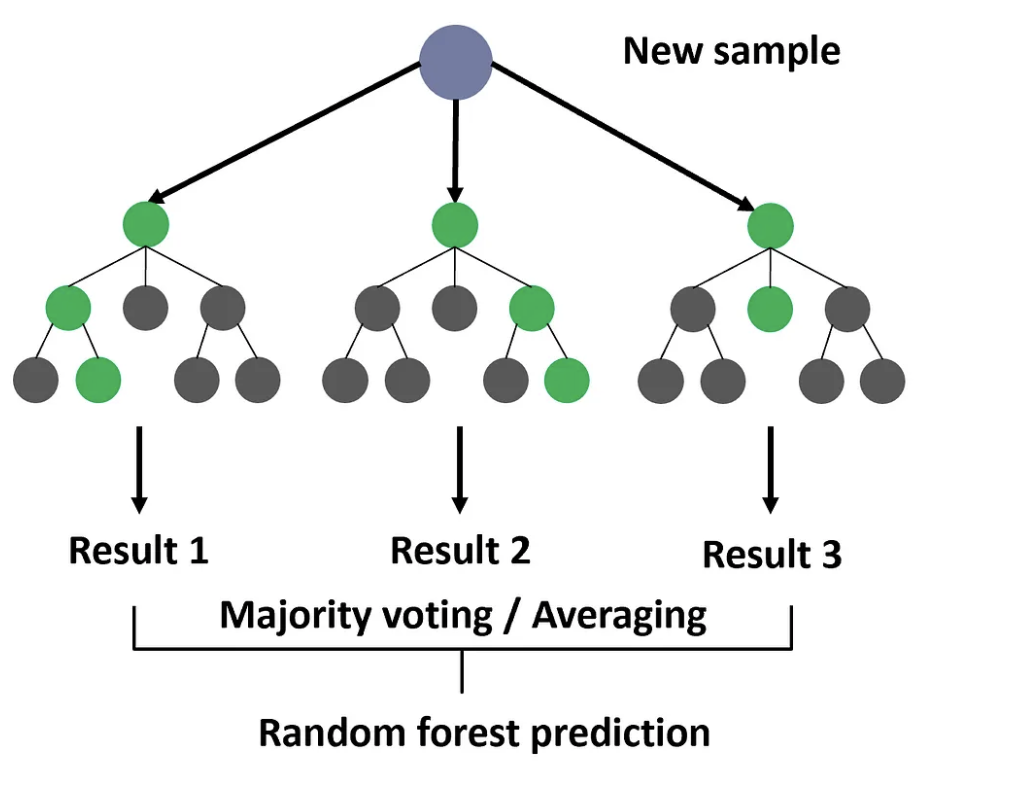

In [63]:
Image('image/6.png')

### Бустинг

Деревья обучаются последовательно, каждое следующее старается улучшить прогноз предыдущего (предсказывает ошибку)
Итоговый ответ - сумма всех деревьев

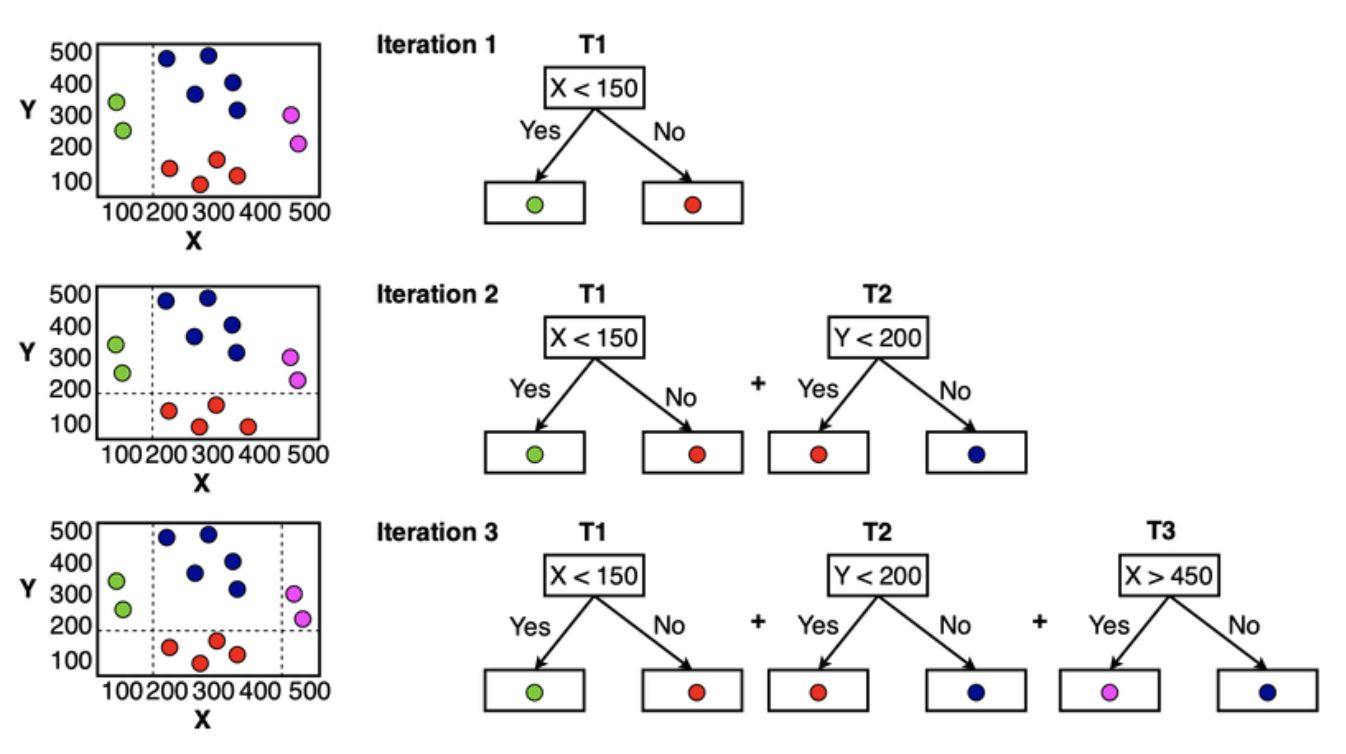

In [64]:
Image('image/7.png')

<i> вернемся к примеру выше </i>

### train-test split, валидация модели

зачем обучать на одном датасете, а проверять на другом?

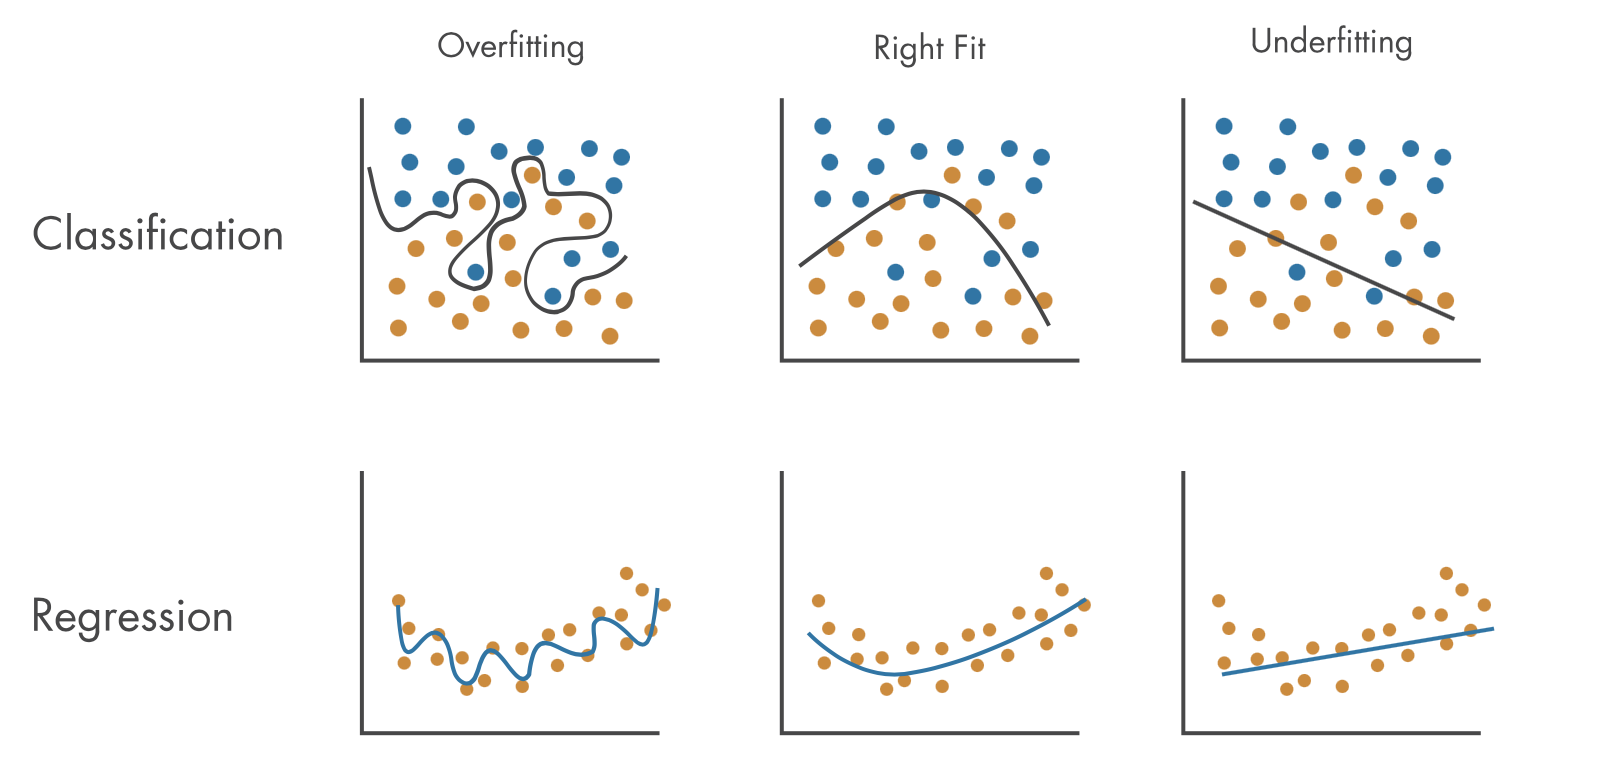

In [65]:
Image('image/9.png')

### Прогноз временных рядов

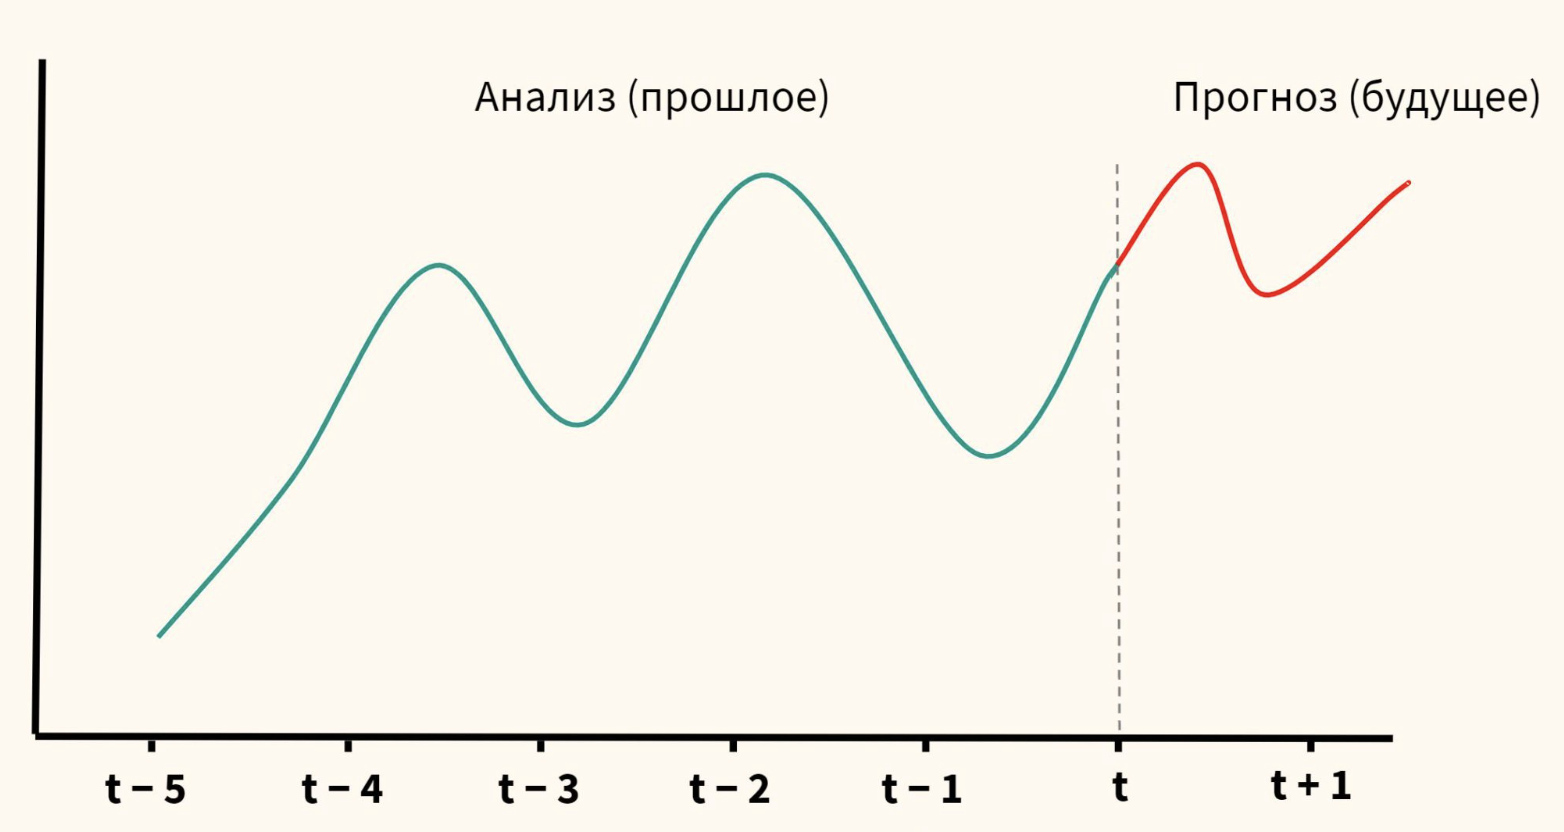

In [73]:
Image('image/13.png')

На первый взгляд признаков нет, только таргеты. Но можно использовать:
    - значения за n периодов назад
    - если во временном ряде наблюдается периодичность, то можно в качестве признака использовать положение внутри периода. Например, остаток от деления на 24 если в почасовых данных есть суточная сезонность

In [74]:
x = np.arange(0, 24*4)
y = np.sin(2*np.pi*x/24)

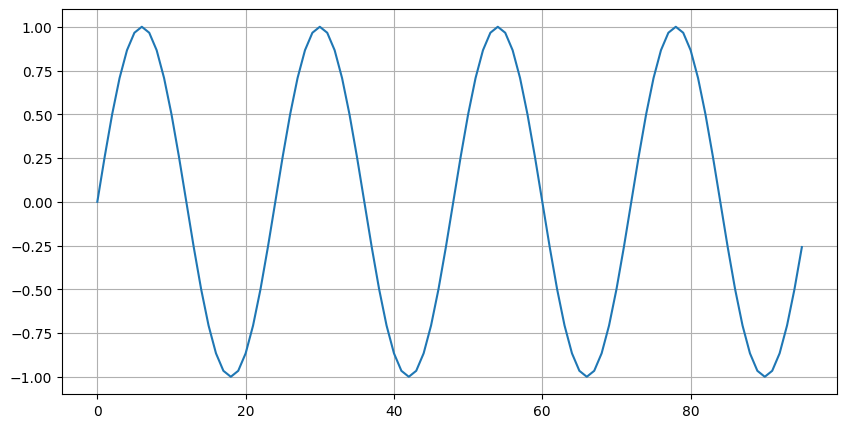

In [75]:
plt.figure(figsize=(10,5))
plt.plot(x,y)
plt.grid()
plt.show()

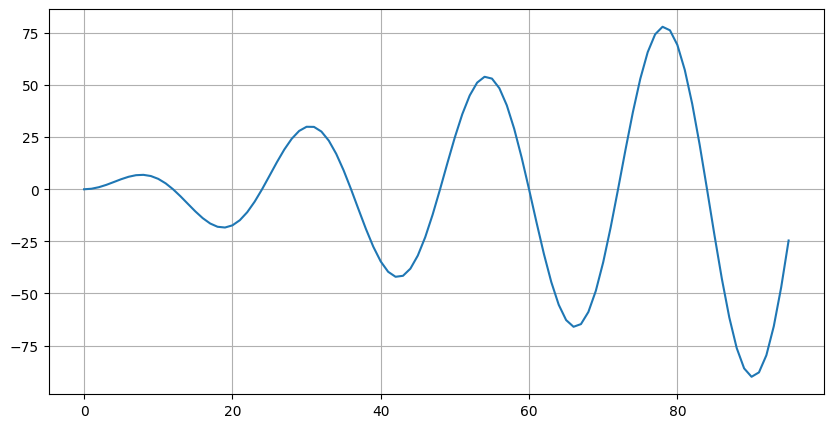

In [76]:
plt.figure(figsize=(10,5))
plt.plot(x,x*y)
plt.grid()
plt.show()

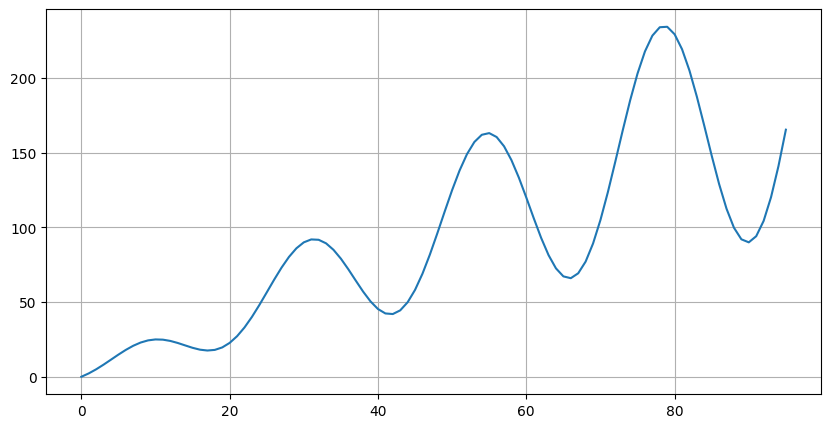

In [77]:
plt.figure(figsize=(10,5))
plt.plot(x,x*y + 2*x)
plt.grid()
plt.show()

#### Особенности валидации

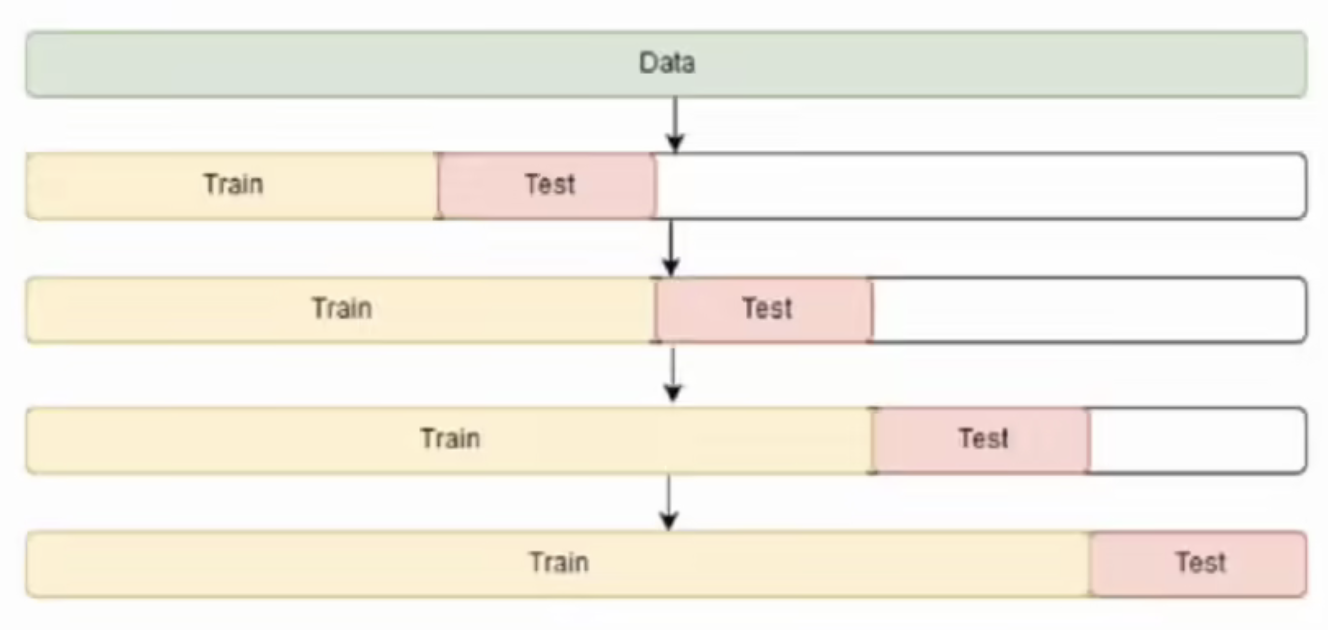

In [78]:
Image('image/12.png')

### Работа с текстом

In [79]:
df_text = pd.read_csv('reviews_train.csv').iloc[:5]

In [80]:
df_text

,text,target
0,Московский квартал 2.\nШумно : летом по ночам ...,0
1,"Не знаю смутят ли кого-то данные правила, но я...",0
2,Хорошие условия аренды. \nДружелюбный персонал...,1
3,Топ мастер Ангелина топ во всех смыслах ) Немн...,1
4,"Приятное общение, все доступно объяснили, мне ...",1


In [81]:
df_text['text'].iloc[4]

'Приятное общение, все доступно объяснили, мне понравилось\n'

In [82]:
from sklearn.feature_extraction.text import CountVectorizer
vect = CountVectorizer()

In [83]:
X = vect.fit_transform(df_text['text'])

In [84]:
pd.DataFrame(X.toarray(), columns=vect.get_feature_names())

/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


,16,194,n1,n2,n3,nвы,nдружелюбный,nно,nпредоставить,nцирк,...,хорошие,хочешь,цена,часа,часто,что,шкаф,щеточки,этаж,это
0,1,1,0,0,0,0,0,0,0,0,...,0,0,1,1,1,0,0,0,1,1
1,0,0,1,1,1,1,0,0,1,1,...,0,1,0,0,0,2,1,0,0,0
2,0,0,0,0,0,0,1,2,0,0,...,1,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [85]:
import pymorphy2

In [86]:
morph = pymorphy2.MorphAnalyzer()

In [87]:
[morph.parse(x)[0].normal_form for x in ['хорошая', 'хороший', 'хорошо']]

['хороший', 'хороший', 'хорошо']

In [88]:
split = 'Приятное общение, все доступно объяснили, мне понравилось\n'.split(' ')

In [89]:
split

['Приятное',
 'общение,',
 'все',
 'доступно',
 'объяснили,',
 'мне',
 'понравилось\n']

In [90]:
[morph.parse(x)[0].normal_form for x in split]

['приятный', 'общение,', 'всё', 'доступно', 'объяснили,', 'я', 'понравилось\n']

In [91]:
[morph.parse(x)[0].normal_form for x in ['объяснили', 'понравилось']]

['объяснить', 'понравиться']

Что можно сделать еще:
    - почистить от лишних символов
    - перейти от CountVectorizer к TfIdfVectorizer и дать более популярным словам меньший вес
    - попробовать указать текстовую фичу в catboost через text_features
    - ...

### Общие рекомендации при обучении моделей

- проведите разведочный анализ датасета. Есть ли пропуски, как распределены признаки, их связь с таргетом
- придумайте новые фичи на основе текущих. Соотношение длины лепестка к ширине, рейтинг футболиста по скорости в его стране/клубе, время суток/час из даты
- пробуйте разные алгоритмы
- проверяйте не переобучились ли модели. Оставляйте часть датасета для проверки

### Дополнительные материалы

Если хочется разобраться в теории
https://academy.yandex.ru/handbook/ml - учебник от Школы Анализы Данных Яндекса

Попробовать ml на практике - https://www.kaggle.com